# WiDS Datathon 2026 — Track 1  
## Accelerating Equitable Wildfire Response — **Leakage-Safe** ML Notebook

**Goal:** predict whether the first alert will be *late* (binary classification).  
**Metric:** ROC-AUC (primary) + confusion matrix & threshold analysis (secondary).  

> **Design rule:** every feature must be available **at or before `reported_time`**.  
We treat anything derived from *alert-time processes* (e.g., evac-zone associations created when the alert happens) as **potential leakage** and exclude it from features.

---

### Notebook roadmap
1. Setup & reproducibility  
2. Data loading  
3. Target construction (**lag** between `reported_time` and `alert_time`)  
4. Leakage checks & train/validation strategy (**group-safe** by `geo_event_id`)  
5. EDA (target, time, geography)  
6. Feature engineering (time, location, source/context; all report-time safe)  
7. Modeling  
   - Baseline: RandomForest  
   - Advanced: CatBoost  
   - Ensemble: CatBoost + XGBoost + LightGBM (soft-vote)  
8. Evaluation (ROC-AUC, ROC curve, confusion matrix, optimal threshold)  
9. Train full model & generate submission (if `test.csv` exists)



In [4]:
# Instalare kaggle (dacă nu este deja disponibil)
!pip -q install kaggle

import os
from pathlib import Path

# Numele competiției
COMPETITION = "wids-university-datathon-2025"

# Directorul unde vor fi extrase datele
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# Verificare kaggle.json
assert os.path.exists("kaggle.json"), (
    "Fișierul kaggle.json nu a fost găsit. "
    "Te rog să-l încarci în Colab (Files → Upload)."
)

# Configurare Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Autentificare Kaggle configurată.")

zip_path = Path(f"{COMPETITION}.zip")

# Descărcare doar dacă arhiva nu există deja
if not zip_path.exists():
    print("Descărcare date din Kaggle...")
    !kaggle competitions download -c {COMPETITION}
else:
    print("Arhiva există deja, nu se descarcă din nou.")

# Extragem fișierele
print("Extragere fișiere în folderul data/ ...")
!unzip -o {zip_path} -d {DATA_DIR}


Autentificare Kaggle configurată.
Descărcare date din Kaggle...
 82% 330M/403M [00:05<00:01, 41.8MB/s]
100% 403M/403M [00:05<00:00, 71.5MB/s]
Extragere fișiere în folderul data/ ...
Archive:  wids-university-datathon-2025.zip
  inflating: data/WiDS _-_ Watch Duty_ Data Dictionary.docx  
  inflating: data/evac_zone_status_geo_event_map.csv  
  inflating: data/evac_zones_gis_evaczone.csv  
  inflating: data/evac_zones_gis_evaczonechangelog.csv  
  inflating: data/fire_perimeters_gis_fireperimeter.csv  
  inflating: data/fire_perimeters_gis_fireperimeterchangelog.csv  
  inflating: data/geo_events_externalgeoevent.csv  
  inflating: data/geo_events_externalgeoeventchangelog.csv  
  inflating: data/geo_events_geoevent.csv  
  inflating: data/geo_events_geoeventchangelog.csv  


In [5]:
# --- Setup & imports ---
import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, RocCurveDisplay, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")  # change if needed
pd.set_option("display.max_columns", 200)

def seed_everything(seed=RANDOM_STATE):
    import random
    random.seed(seed)
    np.random.seed(seed)
seed_everything()

print("DATA_DIR:", DATA_DIR.resolve())


DATA_DIR: /content/data


In [6]:
# --- Data loading ---
# Expected (from the official dataset used in Track 1 notebooks)
# - geo_events_geoevent.csv
# - geo_events_externalgeoevent.csv
# - evac_zone_status_geo_event_map.csv (USED ONLY FOR TARGET, not features)
# - evac_zones_gis_evaczone.csv (NOT USED for features in this leakage-safe version)

def safe_read_csv(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path, low_memory=False)

geo_events = safe_read_csv(DATA_DIR / "geo_events_geoevent.csv")
external_events = safe_read_csv(DATA_DIR / "geo_events_externalgeoevent.csv")
event_zone_map = safe_read_csv(DATA_DIR / "evac_zone_status_geo_event_map.csv")

print("geo_events:", geo_events.shape)
print("external_events:", external_events.shape)
print("event_zone_map:", event_zone_map.shape)

display(geo_events.head(3))


geo_events: (62696, 17)
external_events: (1502495, 14)
event_zone_map: (4429, 3)


,id,date_created,date_modified,geo_event_type,name,is_active,description,address,lat,lng,data,notification_type,external_id,external_source,incident_id,reporter_managed,is_visible
0,76,2021-08-11 00:09:56.481066,2023-02-09 20:34:24.180117,wildfire,Todd Fire,0,NaN,"Llano Rd & Todd Rd, Santa Rosa, California 95...",38.386100,-122.769299,"{""is_fps"": false, ""acreage"": 50, ""containment""...",normal,1008375748,pulsepoint,76.0,1,0
1,77,2021-08-11 07:21:46.054995,2023-02-09 20:34:24.225186,wildfire,Vegetation Fire,0,NaN,"Guerneville Rd & W Steele Ln, Santa Rosa, CA 9...",38.459967,-122.728927,"{""is_fps"": false, ""acreage"": 0, ""containment"":...",normal,1008583077,pulsepoint,77.0,1,0
2,78,2021-08-11 21:02:16.301416,2023-02-09 20:34:24.266124,wildfire,Ford Fire,0,NaN,"CA-1 & Valley Ford Estero Rd, Valley Ford, CA ...",38.318328,-122.925698,"{""is_fps"": false, ""acreage"": 0, ""containment"":...",normal,1008957703,pulsepoint,78.0,1,0


## Target construction (lag)

We create:
- **`reported_time`** = earliest time the incident exists in our system (internal create time or external source time).
- **`alert_time`** = earliest evac-zone association time (proxy for first alert / response action in the system).
- **`lag_hours`** = `alert_time - reported_time` (hours).
- **`late_alert`** = 1 if lag exceeds a threshold (default **1 hour**), else 0.

We then **filter** to realistic ranges and remove missing/negative lag.


In [7]:
# --- Datetime parsing ---
def to_dt(s):
    return pd.to_datetime(s, errors="coerce", utc=True)

geo_events["date_created"] = to_dt(geo_events.get("date_created"))
external_events["date_created"] = to_dt(external_events.get("date_created"))
event_zone_map["date_created"] = to_dt(event_zone_map.get("date_created"))

# --- alert_time (target-side only!) ---
alert_time = (
    event_zone_map.groupby("geo_event_id", as_index=False)["date_created"]
    .min()
    .rename(columns={"date_created":"alert_time"})
)

# --- reported_time ---
reported_internal = geo_events[["id","date_created"]].rename(columns={"id":"geo_event_id","date_created":"reported_internal"})

reported_external = (
    external_events.dropna(subset=["geo_event_id"])
    .groupby("geo_event_id", as_index=False)["date_created"]
    .min()
    .rename(columns={"date_created":"reported_external"})
)

reported_time = reported_internal.merge(reported_external, on="geo_event_id", how="left")
reported_time["reported_time"] = reported_time[["reported_internal","reported_external"]].min(axis=1)

# --- combine and compute lag ---
target = reported_time.merge(alert_time, on="geo_event_id", how="left")

target["lag_hours"] = (target["alert_time"] - target["reported_time"]).dt.total_seconds()/3600

# Diagnostics
print("Missing alert_time:", target["alert_time"].isna().mean())
print("Missing reported_time:", target["reported_time"].isna().mean())
print("Negative lag:", (target["lag_hours"] < 0).mean())

display(target["lag_hours"].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]))

# Keep plausible range: 0..168 hours (7 days)
df_lag = target.dropna(subset=["reported_time","alert_time","lag_hours"]).copy()
df_lag = df_lag[(df_lag["lag_hours"] >= 0) & (df_lag["lag_hours"] <= 168)].copy()

# Threshold definition (competition-reasonable default)
LATE_THRESHOLD_HOURS = 1.0
df_lag["late_alert"] = (df_lag["lag_hours"] > LATE_THRESHOLD_HOURS).astype(int)

print("Rows kept:", len(df_lag))
print("Late rate:", df_lag["late_alert"].mean())

df_lag.head()


Missing alert_time: 0.9925354089575092
Missing reported_time: 0.0
Negative lag: 0.0


,lag_hours
count,468.000000
mean,15.653337
std,58.381839
min,0.003858
1%,0.010410
5%,0.143131
50%,1.085673
95%,75.643160
99%,376.540984
max,577.570806


Rows kept: 455
Late rate: 0.5208791208791209


,geo_event_id,reported_internal,reported_external,reported_time,alert_time,lag_hours,late_alert
13982,14107,2023-10-25 09:09:37.315114+00:00,NaT,2023-10-25 09:09:37.315114+00:00,2023-10-25 11:28:15.254517+00:00,2.310539,1
14380,14505,2023-11-02 21:48:54.382851+00:00,NaT,2023-11-02 21:48:54.382851+00:00,2023-11-02 21:52:49.867450+00:00,0.065412,0
18660,18785,2024-05-02 20:22:15.121138+00:00,NaT,2024-05-02 20:22:15.121138+00:00,2024-05-02 20:53:00.964490+00:00,0.512734,0
18954,19079,2024-05-09 22:35:59.339014+00:00,NaT,2024-05-09 22:35:59.339014+00:00,2024-05-09 22:40:23.873510+00:00,0.073482,0
18993,19118,2024-05-10 17:20:38.485321+00:00,NaT,2024-05-10 17:20:38.485321+00:00,2024-05-10 18:06:08.096668+00:00,0.758225,0


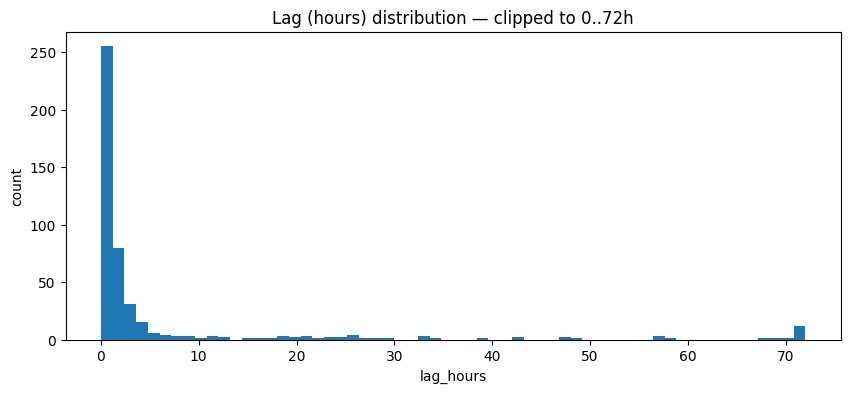

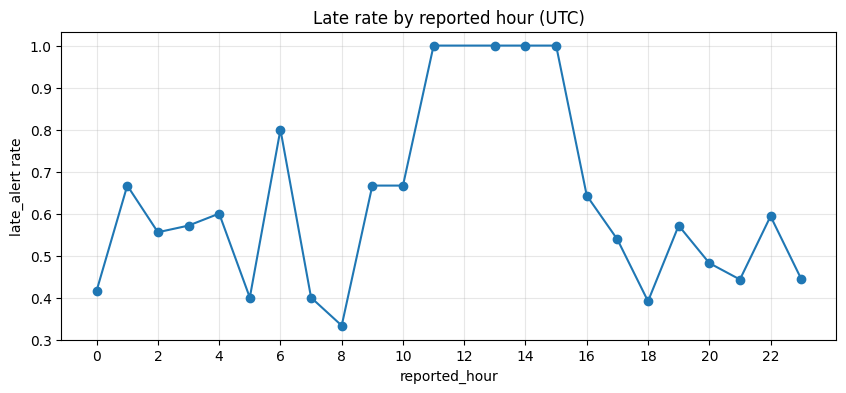

In [8]:
# --- EDA: lag distribution ---
plt.figure(figsize=(10,4))
x = df_lag["lag_hours"].clip(0, 72)
plt.hist(x, bins=60)
plt.title("Lag (hours) distribution — clipped to 0..72h")
plt.xlabel("lag_hours")
plt.ylabel("count")
plt.show()

# Late rate over hour-of-day (reported_time)
tmp = df_lag.copy()
tmp["reported_hour"] = tmp["reported_time"].dt.hour
rate = tmp.groupby("reported_hour")["late_alert"].mean()

plt.figure(figsize=(10,4))
plt.plot(rate.index, rate.values, marker="o")
plt.title("Late rate by reported hour (UTC)")
plt.xlabel("reported_hour")
plt.ylabel("late_alert rate")
plt.xticks(range(0,24,2))
plt.grid(True, alpha=0.3)
plt.show()


## Feature engineering (report-time safe)

We **do not** use evac-zone mappings or any feature created at `alert_time`.  
Instead, we use only:
- Incident metadata from `geo_events` (type/source/context)
- Location (`lat`, `lng`)
- Time features from `reported_time` (hour, weekday, month + cyclical encoding)
- Spatial clustering from lat/lng (KMeans label)

This keeps the notebook robust and minimizes the risk of “too good to be true” ROC-AUC due to leakage.


In [12]:
# --- Build modeling frame (features + target) ---
# Keep only wildfire records (if column exists)
df_meta = geo_events.copy()
if "geo_event_type" in df_meta.columns:
    df_meta = df_meta[df_meta["geo_event_type"].fillna("").str.lower().eq("wildfire")].copy()

# Minimal metadata set (guard with .get)
meta_cols = [
    "id","geo_event_type","lat","lng",
    "notification_type","external_source","source_type"
]
meta_cols = [c for c in meta_cols if c in df_meta.columns]
df_meta = df_meta[meta_cols].rename(columns={"id":"geo_event_id"})

df = df_lag.merge(df_meta, on="geo_event_id", how="left")

# --- Time features from reported_time ---
df["reported_hour"] = df["reported_time"].dt.hour.astype("Int32")
df["reported_weekday"] = df["reported_time"].dt.weekday.astype("Int32")
df["reported_month"] = df["reported_time"].dt.month.astype("Int32")

df["is_weekend"] = (df["reported_weekday"] >= 5).astype("Int8")
df["is_night"] = ((df["reported_hour"] <= 6) | (df["reported_hour"] >= 20)).astype("Int8")

# Cyclical time encoding
df["hour_sin"] = np.sin(2*np.pi*df["reported_hour"].astype(float)/24)
df["hour_cos"] = np.cos(2*np.pi*df["reported_hour"].astype(float)/24)
df["month_sin"] = np.sin(2*np.pi*df["reported_month"].astype(float)/12)
df["month_cos"] = np.cos(2*np.pi*df["reported_month"].astype(float)/12)

# --- Spatial clustering (KMeans) ---
from sklearn.cluster import KMeans

df["lat"] = pd.to_numeric(df.get("lat"), errors="coerce")
df["lng"] = pd.to_numeric(df.get("lng"), errors="coerce")

coords = df[["lat","lng"]].dropna()
K = 30 if len(coords) >= 500 else (20 if len(coords) >= 200 else max(5, len(coords)//20))
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init="auto")
kmeans.fit(coords)

df["geo_cluster"] = -1
df.loc[coords.index, "geo_cluster"] = kmeans.labels_.astype("int") # Changed from "Int32" to "int"

# --- Final feature set ---
feature_cols = [
    "lat","lng","geo_cluster",
    "reported_hour","reported_weekday","reported_month",
    "is_weekend","is_night",
    "hour_sin","hour_cos","month_sin","month_cos",
    "geo_event_type","notification_type","external_source","source_type"
]
feature_cols = [c for c in feature_cols if c in df.columns]

df_model = df.dropna(subset=["late_alert"]).copy()
y = df_model["late_alert"].astype(int).values
groups = df_model["geo_event_id"].values

X = df_model[feature_cols].copy()

print("X shape:", X.shape, "y mean:", y.mean(), "clusters:", df_model["geo_cluster"].nunique())
display(df_model[feature_cols + ["late_alert","lag_hours"]].head(3))


X shape: (455, 15) y mean: 0.5208791208791209 clusters: 20


,lat,lng,geo_cluster,reported_hour,reported_weekday,reported_month,is_weekend,is_night,hour_sin,hour_cos,month_sin,month_cos,geo_event_type,notification_type,external_source,late_alert,lag_hours
0,39.521072,-120.007334,9,9,2,10,0,0,0.707107,-0.707107,-0.866025,0.500000,wildfire,normal,NaN,1,2.310539
1,39.854363,-121.910366,9,21,3,11,0,1,-0.707107,0.707107,-0.500000,0.866025,wildfire,silent,NaN,0,0.065412
2,35.047334,-119.329033,6,20,3,5,0,1,-0.866025,0.500000,0.500000,-0.866025,wildfire,normal,NaN,0,0.512734


## Leakage-safe validation: Group split by `geo_event_id`

We must not allow the same incident (`geo_event_id`) to appear in both train and validation.
We'll use:
- **Holdout split** with `GroupShuffleSplit` for final reporting.
- **GroupKFold CV** for more stable estimates and ensemble weighting.


In [13]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, valid_idx = next(gss.split(X, y, groups=groups))

X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[valid_idx].copy()
y_train, y_valid = y[train_idx], y[valid_idx]
g_train, g_valid = groups[train_idx], groups[valid_idx]

print("Train:", X_train.shape, "Valid:", X_valid.shape)
print("Valid late rate:", y_valid.mean())


Train: (364, 15) Valid: (91, 15)
Valid late rate: 0.5494505494505495


## Model 1 — Baseline RandomForest (strong, fast, interpretable)

We use a preprocessing pipeline:
- numeric: median imputation
- categorical: most-frequent imputation + one-hot


RF holdout ROC-AUC: 0.7087804878048781


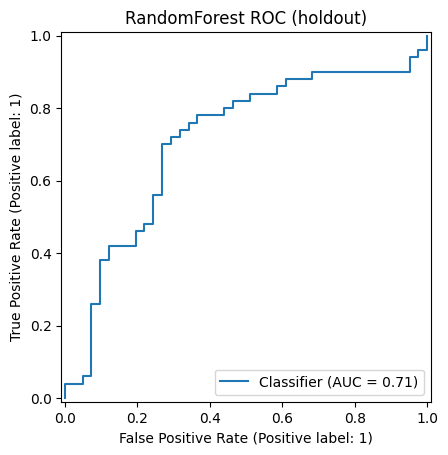

In [14]:
# Identify columns
cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype).startswith("string")]
num_cols = [c for c in X.columns if c not in cat_cols]

numeric_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols),
    ],
    remainder="drop",
)

rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
)

rf_pipe = Pipeline(steps=[("prep", preprocess), ("model", rf)])
rf_pipe.fit(X_train, y_train)

p_valid = rf_pipe.predict_proba(X_valid)[:,1]
auc = roc_auc_score(y_valid, p_valid)
print("RF holdout ROC-AUC:", auc)

RocCurveDisplay.from_predictions(y_valid, p_valid)
plt.title("RandomForest ROC (holdout)")
plt.show()


In [15]:
# --- Confusion matrix & threshold analysis ---
def eval_at_threshold(y_true, p, thr=0.5, label="model"):
    y_hat = (p >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    print(f"== {label} @ thr={thr:.2f} ==")
    print("Confusion matrix:\n", cm)
    print(classification_report(y_true, y_hat, digits=3))
    return cm

# Default 0.5
eval_at_threshold(y_valid, p_valid, 0.5, "RF")

# Best Youden's J threshold
from sklearn.metrics import roc_curve
fpr, tpr, thr = roc_curve(y_valid, p_valid)
j = tpr - fpr
best_thr = thr[np.argmax(j)]
print("Best Youden threshold:", best_thr)
eval_at_threshold(y_valid, p_valid, float(best_thr), "RF (Youden)")


== RF @ thr=0.50 ==
Confusion matrix:
 [[28 13]
 [13 37]]
              precision    recall  f1-score   support

           0      0.683     0.683     0.683        41
           1      0.740     0.740     0.740        50

    accuracy                          0.714        91
   macro avg      0.711     0.711     0.711        91
weighted avg      0.714     0.714     0.714        91

Best Youden threshold: 0.5256630188770066
== RF (Youden) @ thr=0.53 ==
Confusion matrix:
 [[30 11]
 [15 35]]
              precision    recall  f1-score   support

           0      0.667     0.732     0.698        41
           1      0.761     0.700     0.729        50

    accuracy                          0.714        91
   macro avg      0.714     0.716     0.713        91
weighted avg      0.718     0.714     0.715        91



array([[30, 11],
       [15, 35]])

## Model 2 — CatBoost (advanced)

CatBoost handles categorical variables natively (no one-hot needed) and is often very strong on tabular data.

We also set class balancing based on the training split.


0:	test: 0.5739024	best: 0.5739024 (0)	total: 64.5ms	remaining: 4m 17s
200:	test: 0.6507317	best: 0.6521951 (199)	total: 1.51s	remaining: 28.5s
400:	test: 0.6931707	best: 0.6936585 (397)	total: 2.94s	remaining: 26.4s
600:	test: 0.7034146	best: 0.7034146 (582)	total: 3.94s	remaining: 22.3s
800:	test: 0.7087805	best: 0.7126829 (721)	total: 4.57s	remaining: 18.2s
1000:	test: 0.7117073	best: 0.7136585 (849)	total: 5.2s	remaining: 15.6s
1200:	test: 0.7156098	best: 0.7165854 (1190)	total: 5.82s	remaining: 13.6s
1400:	test: 0.7180488	best: 0.7200000 (1384)	total: 6.47s	remaining: 12s
1600:	test: 0.7224390	best: 0.7229268 (1575)	total: 7.77s	remaining: 11.6s
1800:	test: 0.7234146	best: 0.7243902 (1775)	total: 9.36s	remaining: 11.4s
2000:	test: 0.7248780	best: 0.7253659 (1937)	total: 11.9s	remaining: 11.8s
2200:	test: 0.7239024	best: 0.7268293 (2068)	total: 12.6s	remaining: 10.3s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7268292683
bestIteration = 2068

Shrink model t

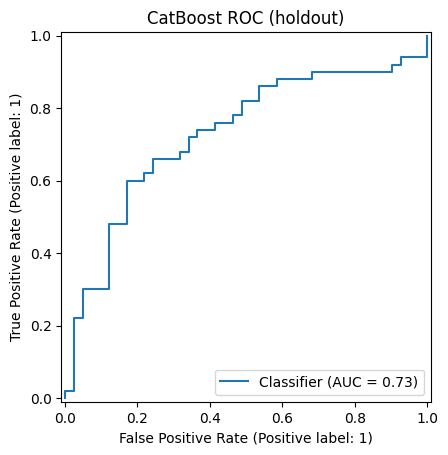

== CatBoost @ thr=0.50 ==
Confusion matrix:
 [[27 14]
 [16 34]]
              precision    recall  f1-score   support

           0      0.628     0.659     0.643        41
           1      0.708     0.680     0.694        50

    accuracy                          0.670        91
   macro avg      0.668     0.669     0.668        91
weighted avg      0.672     0.670     0.671        91



In [19]:
# --- CatBoost ---
# If running on Kaggle/Colab, CatBoost should be available. If not, install it.

!pip install catboost

try:
    from catboost import CatBoostClassifier
    catboost_ok = True
except Exception as e:
    catboost_ok = False
    print("CatBoost not available:", e)

if catboost_ok:
    # CatBoost wants indices of categorical columns
    cat_features = [X_train.columns.get_loc(c) for c in cat_cols]

    # Handle NaN values in categorical columns for CatBoost
    for col in cat_cols:
        X_train[col] = X_train[col].fillna("").astype(str)
        X_valid[col] = X_valid[col].fillna("").astype(str)

    # scale_pos_weight
    neg = (y_train==0).sum()
    pos = (y_train==1).sum()
    spw = neg / max(pos, 1)

    cb = CatBoostClassifier(
        iterations=4000,
        learning_rate=0.03,
        depth=7,
        l2_leaf_reg=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        scale_pos_weight=spw,
        subsample=0.8,
        colsample_bylevel=0.8,
        early_stopping_rounds=200,
        verbose=200,
        allow_writing_files=False,
    )

    cb.fit(
        X_train, y_train,
        cat_features=cat_features,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

    p_cb = cb.predict_proba(X_valid)[:,1]
    auc_cb = roc_auc_score(y_valid, p_cb)
    print("CatBoost holdout ROC-AUC:", auc_cb)

    RocCurveDisplay.from_predictions(y_valid, p_cb)
    plt.title("CatBoost ROC (holdout)")
    plt.show()

    eval_at_threshold(y_valid, p_cb, 0.5, "CatBoost")


## Model 3 — Ensemble (CatBoost + XGBoost + LightGBM)

We train all three (if available) and use **soft voting** (mean of probabilities).  
For stability, we compute CV ROC-AUC per model and use those scores as weights.

> If XGBoost/LightGBM are not installed in your environment, the ensemble will gracefully fall back to the available models.


In [21]:
!pip install xgboost lightgbm

Datele de ieșire de afișat au fost trunchiate la ultimele 5000 linii.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

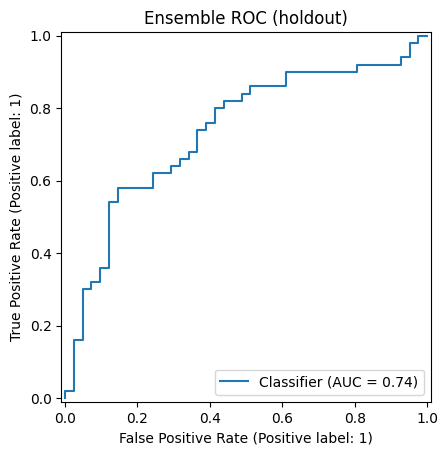

== Ensemble @ thr=0.50 ==
Confusion matrix:
 [[27 14]
 [16 34]]
              precision    recall  f1-score   support

           0      0.628     0.659     0.643        41
           1      0.708     0.680     0.694        50

    accuracy                          0.670        91
   macro avg      0.668     0.669     0.668        91
weighted avg      0.672     0.670     0.671        91



array([[27, 14],
       [16, 34]])

In [23]:
# --- Optional: XGBoost & LightGBM ---
xgb_ok = lgb_ok = True
try:
    import xgboost as xgb
except Exception as e:
    xgb_ok = False
    print("XGBoost not available:", e)

try:
    import lightgbm as lgb
except Exception as e:
    lgb_ok = False
    print("LightGBM not available:", e)

# We'll train models with the SAME preprocessing as RF for XGB/LGB (one-hot for categoricals)
# because these libraries typically expect numeric matrices.
from sklearn.metrics import roc_auc_score

# --- CV scoring for weights ---
gkf = GroupKFold(n_splits=5)

def cv_auc_model(model_name):
    aucs=[]
    for fold,(tr,va) in enumerate(gkf.split(X, y, groups=groups),1):
        Xtr, Xva = X.iloc[tr], X.iloc[va]
        ytr, yva = y[tr], y[va]

        if model_name=="catboost":
            if not catboost_ok:
                return None
            # Handle NaN values in categorical columns for CatBoost within CV loop
            for col in cat_cols:
                Xtr[col] = Xtr[col].fillna("").astype(str)
                Xva[col] = Xva[col].fillna("").astype(str)

            cat_features = [Xtr.columns.get_loc(c) for c in cat_cols]
            neg = (ytr==0).sum(); pos=(ytr==1).sum(); spw=neg/max(pos,1)
            m = CatBoostClassifier(
                iterations=2500, learning_rate=0.03, depth=7,
                loss_function="Logloss", eval_metric="AUC",
                random_seed=RANDOM_STATE, scale_pos_weight=spw,
                subsample=0.8, colsample_bylevel=0.8,
                early_stopping_rounds=150, verbose=False,
                allow_writing_files=False,
            )
            m.fit(Xtr, ytr, cat_features=cat_features, eval_set=(Xva,yva), use_best_model=True)
            p = m.predict_proba(Xva)[:,1]

        elif model_name=="xgb":
            if not xgb_ok:
                return None
            m = Pipeline([("prep", preprocess), ("model", xgb.XGBClassifier(
                n_estimators=2500, learning_rate=0.03, max_depth=6,
                subsample=0.85, colsample_bytree=0.85,
                reg_lambda=2.0, min_child_weight=1.0,
                objective="binary:logistic", eval_metric="auc",
                tree_method="hist", random_state=RANDOM_STATE
            ))])
            m.fit(Xtr, ytr)
            p = m.predict_proba(Xva)[:,1]

        elif model_name=="lgb":
            if not lgb_ok:
                return None
            m = Pipeline([("prep", preprocess), ("model", lgb.LGBMClassifier(
                n_estimators=4000, learning_rate=0.03, num_leaves=64,
                subsample=0.85, colsample_bytree=0.85, reg_lambda=2.0,
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))])
            m.fit(Xtr, ytr)
            p = m.predict_proba(Xva)[:,1]
        else:
            raise ValueError(model_name)

        aucs.append(roc_auc_score(yva, p))
    return float(np.mean(aucs)), float(np.std(aucs))

scores = {}
for name in ["catboost","xgb","lgb"]:
    out = cv_auc_model(name)
    if out is not None:
        scores[name] = out
        print(f"{name}: AUC mean={out[0]:.5f} std={out[1]:.5f}")

# --- Train available models on holdout split ---
probs = []
weights = []

# CatBoost (already fitted in previous section)
if catboost_ok:
    if "p_cb" in globals():
        probs.append(p_cb)
        weights.append(scores.get("catboost",(1.0,0))[0])

# XGB on holdout
if xgb_ok:
    xgb_pipe = Pipeline([("prep", preprocess), ("model", xgb.XGBClassifier(
        n_estimators=4000, learning_rate=0.03, max_depth=6,
        subsample=0.85, colsample_bytree=0.85,
        reg_lambda=2.0, min_child_weight=1.0,
        objective="binary:logistic", eval_metric="auc",
        tree_method="hist", random_state=RANDOM_STATE
    ))])
    xgb_pipe.fit(X_train, y_train)
    p_xgb = xgb_pipe.predict_proba(X_valid)[:,1]
    probs.append(p_xgb); weights.append(scores.get("xgb",(1.0,0))[0])
    print("XGB holdout AUC:", roc_auc_score(y_valid, p_xgb))

# LGB on holdout
if lgb_ok:
    lgb_pipe = Pipeline([("prep", preprocess), ("model", lgb.LGBMClassifier(
        n_estimators=6000, learning_rate=0.03, num_leaves=64,
        subsample=0.85, colsample_bytree=0.85,
        reg_lambda=2.0, random_state=RANDOM_STATE,
        class_weight="balanced"
    ))])
    lgb_pipe.fit(X_train, y_train)
    p_lgb = lgb_pipe.predict_proba(X_valid)[:,1]
    probs.append(p_lgb); weights.append(scores.get("lgb",(1.0,0))[0])
    print("LGB holdout AUC:", roc_auc_score(y_valid, p_lgb))

if len(probs) == 0:
    raise RuntimeError("No ensemble models available in this environment.")

# --- Weighted soft vote ---
weights = np.array(weights, dtype=float)
weights = weights / weights.sum()

p_ens = np.average(np.vstack(probs), axis=0, weights=weights)
auc_ens = roc_auc_score(y_valid, p_ens)
print("Ensemble holdout ROC-AUC:", auc_ens)

RocCurveDisplay.from_predictions(y_valid, p_ens)
plt.title("Ensemble ROC (holdout)")
plt.show()

eval_at_threshold(y_valid, p_ens, 0.5, "Ensemble")


## Train full model & create submission

If your competition provides a separate test set (e.g., `test.csv` or similar),
add a cell here to load it, build the same **report-time safe** features, train the chosen model on **all** labeled data, and write `submission.csv`.

Below is a template that you can adapt once you confirm the official test file name and required submission columns.


In [24]:
# --- Submission template (adapt to the official test file) ---
# Example assumptions:
# - test file: data/test.csv
# - submission expects: geo_event_id, late_alert_probability
#
# If you already have an official sample_submission.csv, prefer reading it and filling the prediction column.

TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUB_PATH = DATA_DIR / "sample_submission.csv"

if TEST_PATH.exists():
    test_raw = pd.read_csv(TEST_PATH, low_memory=False)
    print("test_raw:", test_raw.shape)

    # IMPORTANT: build the same feature columns as training (report-time safe only).
    # You will need reported_time for test as well (depending on how the organizers define it).
    # If test already includes reported_time, parse it; otherwise compute similarly to training.

    # Placeholder:
    # test_df = ...
    # X_test = test_df[feature_cols]

    # Choose best model from holdout: ensemble > catboost > rf
    # final_model = ...
    # p_test = final_model.predict_proba(X_test)[:,1]

    # Create submission
    if SAMPLE_SUB_PATH.exists():
        sub = pd.read_csv(SAMPLE_SUB_PATH)
        display(sub.head())
        # sub["prediction"] = p_test
    else:
        sub = pd.DataFrame({"geo_event_id": test_raw["geo_event_id"], "late_alert_probability": np.nan})

    # sub.to_csv("submission.csv", index=False)
    print("Template ready. Fill feature creation + prediction, then write submission.csv")
else:
    print("No test.csv found. If you're on Kaggle, confirm the official test file name and required submission format.")


No test.csv found. If you're on Kaggle, confirm the official test file name and required submission format.
